In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import sys
import os
# Ensure project folder is in the path (adjust as needed)
#sys.path.append(os.path.abspath(os.path.join('../../../')))

from AIedes.models.counter_models import (
    PositiveFeedForwardAbundanceModel,
    PositiveLSTMAbundanceModel,
    PositiveMultiHeadAttentionModel,
    PositiveHurdleModel
)
from AIedes.train.counter_train import train_mosquito_net

from AIedes.data_loader.counter_data_loader import (
    load_and_process_data,
    prepare_data,
)

from AIedes.utils.counter_losses import get_criterion



In [2]:

random_state = 3
dropout_rate = 0.2
layers = 2
hidden_size = 64
bs = 64
learning_rate = "5e-05"  # From your data (appears to be consistent)

input_variables = "t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn"
#input_variables = "t2m_mean_norm+prev2_weeklyRates_norm+prev_weeklyRates_norm+tp_sum_norm+d2m_mean_norm"
#name_file = f"modelpositive_ff_lossFrequencyWeighted_hid{hidden_size}_lay{layers}_do{dropout_rate}_lr{learning_rate}_bs{bs}_sd{random_state}_{input_variables}"
#name_file = "modelpositive_ff_lossFrequencyWeighted_hid16_lay3_do0.2_lr1e-04_bs32_sd2_t2m_mean_norm+prev2_weeklyRates_norm+prev_weeklyRates_norm+tp_sum_norm+d2m_mean_norm"
#name_file = "modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.2_lr1e-03_bs64_sd2_t2m_mean_znorm+tp_sum_znorm+p1zn+p2zn"
name_file = "modelpositive_ff_lossFrequencyWeightedMSLE_hid32_lay2_do0.2_lr1e-03_bs64_sd15_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn"

path = "../../data/"
df = pd.read_pickle(path + name_file + "_results.pkl")
model = torch.load(path+name_file + ".pth", map_location=torch.device('cpu'), weights_only=False)

In [3]:
# load a xarray climate data file
import xarray as xr
yr = 2020
climate_data = f"../../data/europe_copernicus_data_{yr}.nc"
ds = xr.open_dataset(climate_data)
# add Nan WeeklyRates with the same lat lon and time of temperature
ds['WeeklyRates'] = xr.full_like(ds['2m_temperature_mean'], np.nan)


In [4]:
import xarray as xr
from datetime import datetime
# load ds
output_file = "../../data/predictions_2020_weekly_rates.nc"
# print the file data creation date
stat = os.stat(output_file)
print("Creation (ctime):", datetime.fromtimestamp(stat.st_ctime))
print("Modification (mtime):", datetime.fromtimestamp(stat.st_mtime))
ds = xr.open_dataset(output_file)
# print the file data creation date


Creation (ctime): 2025-09-17 14:58:36.815876
Modification (mtime): 2025-09-17 14:58:36.815876


In [5]:
import numpy as np
import pandas as pd
import geopandas as gpd


parent_dir = "/home/biazzin/git/mimesis/data/ourdata/copernicus_ecdc/"
parent_dir = "../../../classificator/data/"
year = "2020"
df = pd.read_csv(parent_dir + f'albopictus_presence_absence_ecdc_copernicus_{year}.zip')
#df_suitable = df[df['Suitable'] == 1]  # Select only the suitable records
df_suitable = df
df_Presence_Absence = df_suitable.copy()
df_Presence_Absence["NUTS3_Code"] = df_Presence_Absence["LocationCode"]
# set presence absence to 1 if suitable is 1, otherwise set to 0
df_Presence_Absence["Presence_Absence"] = ((df_Presence_Absence['presence_numeric'] == 1) & (df_Presence_Absence['Suitable'] == 1)).astype(int)
df_gdf = gpd.GeoDataFrame(df_Presence_Absence, geometry=gpd.points_from_xy(df_Presence_Absence['longitude'], df_Presence_Absence['latitude']))
df_Presence_Absence = df_gdf.copy()

from AIedes.data_loader.classificator_data_loader import normalize_temperature_df, normalize_precipitation_df

df_Presence_Absence = normalize_temperature_df(df_Presence_Absence)
df_Presence_Absence = normalize_precipitation_df(df_Presence_Absence)

features = ['temp_Jan_C', 'temp_Feb_C', 'temp_Mar_C', 'temp_Apr_C', 
            'temp_May_C', 'temp_Jun_C', 'temp_Jul_C', 'temp_Aug_C', 
            'temp_Sep_C', 'temp_Oct_C', 'temp_Nov_C', 'temp_Dec_C', 'precip_Jan_mm',
            'precip_Feb_mm', 'precip_Mar_mm', 'precip_Apr_mm',
            'precip_May_mm', 'precip_Jun_mm', 'precip_Jul_mm', 'precip_Aug_mm',
            'precip_Sep_mm', 'precip_Oct_mm', 'precip_Nov_mm', 'precip_Dec_mm']
datas = {}
df_years = {}

data = df_Presence_Absence[features + ["Presence_Absence"]].to_numpy()

import importlib
import torch
# set threads to 1 to avoid issues with multiprocessing in Jupyter notebooks
torch.set_num_threads(4)
# set number of cpu threads to 1 to avoid issues with multiprocessing in Jupyter notebooks
#torch.set_num_interop_threads(4)

import importlib
from locale import normalize
from AIedes.data_loader.classificator_data_loader import get_data_loaders
# Get data loaders and input size
batch_size = 1024
learning_rate = 0.002
random_seed = 42

train_loaders = {}
test_loaders = {}
train_loader_order, test_loader_order, input_size_order, _ = get_data_loaders(
    data=data, batch_size = batch_size, test_ratio = 1, random_seed = random_seed, shuffle = False, normalize=False
)

import pandas as pd
import pickle
from AIedes.train.classificator_train    import run_model
from AIedes.evaluation.classificator_evaluate import evaluate_model_nuts3, evaluate_model

# read all the result and models files that have "temp_tp" in the name
# list in the current directory that have "temp_tp" in the name
import glob
results_files = glob.glob("../../../classificator/results/res/results_and_models*temp_tp.pkl")
print("Results files found:", results_files)
res_df = []
for name_file in results_files:
    print("Loading file:", name_file)
    with open(name_file, 'rb') as f:
        results = pickle.load(f)
    #print("Results loaded:", results)
    res_df.append(results)
res_df = pd.concat(res_df, ignore_index=True)

def compute_suitability_index(model_, data_loader_):
    with torch.no_grad():
        res = []
        for data in data_loader_:
            inputs, labels = data
            outputs = torch.sigmoid(model_(inputs))
            res.append(outputs)
    return torch.cat(res)
def pred_str(true, pred):
    return 'True Pos.' if true == 1 and pred == 1 else 'True Neg.' if true == 0 and pred == 0 else 'False Neg.' if true == 1 and pred == 0 else 'False Pos.'

res_df.hidden_layers = res_df.hidden_layers.apply(lambda x: str(x))

model_info = res_df[res_df["hidden_layers"] == "[50, 50, 50]"]
net_ = model_info["model"].values[0][0]
df_temp = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_temp["predicted_estim_risk"] = compute_suitability_index(net_, test_loader_order).numpy()
df_temp["predicted"] = df_temp["predicted_estim_risk"] > 0.3
df_temp["results"] = df_temp.apply(lambda x: pred_str(x["Presence_Absence"], x["predicted"]), axis=1)



temp_cols ['temp_Jan_C', 'temp_Feb_C', 'temp_Mar_C', 'temp_Apr_C', 'temp_May_C', 'temp_Jun_C', 'temp_Jul_C', 'temp_Aug_C', 'temp_Sep_C', 'temp_Oct_C', 'temp_Nov_C', 'temp_Dec_C']
Temperature columns normalized with mean and std.
precip_cols ['precip_Jan_mm', 'precip_Feb_mm', 'precip_Mar_mm', 'precip_Apr_mm', 'precip_May_mm', 'precip_Jun_mm', 'precip_Jul_mm', 'precip_Aug_mm', 'precip_Sep_mm', 'precip_Oct_mm', 'precip_Nov_mm', 'precip_Dec_mm']
Precipitation columns normalized with mean and std.
Results files found: ['../../../classificator/results/res/results_and_models_2020_[]_temp_tp.pkl', '../../../classificator/results/res/results_and_models_2020_[10, 10, 10]_temp_tp.pkl', '../../../classificator/results/res/results_and_models_2020_[10, 10]_temp_tp.pkl', '../../../classificator/results/res/results_and_models_2020_[10]_temp_tp.pkl', '../../../classificator/results/res/results_and_models_2020_[20, 20, 20]_temp_tp.pkl', '../../../classificator/results/res/results_and_models_2020_[20, 20

/home/biazzin/git/AIedes/src/AIedes/data_loader/classificator_data_loader.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.float)  # Labels for classification


In [6]:
import xarray as xr
import regionmask
import numpy as np

# 1) Build a 2D land mask (True on land, False on water/lakes)
lon1d = ds["longitude"].values       # shape (701,)
lat1d = ds["latitude"].values        # shape (391,)

# Natural Earth land polygons (use land_110 for coarser, land_50 for finer)
land = regionmask.defined_regions.natural_earth_v5_0_0.land_50

# IMPORTANT: pass **1D** lon, lat (no meshgrid, no time)
mask_idx = land.mask(lon1d, lat1d)   # dims: ('lat','lon'), values: region id or NaN
mask_idx = mask_idx.rename({'lat': 'latitude', 'lon': 'longitude'})

land_mask = xr.DataArray(
    ~np.isnan(mask_idx),              # True on land
    dims=("latitude","longitude"),
    coords={"latitude": ds.latitude, "longitude": ds.longitude}
)
# Mask multiple major lakes
# Lake Ladoga: ~60-62°N, 31-33°E
# Lake Onega: ~61-62.5°N, 35-37°E  
# White Sea (if needed): ~64-67°N, 33-42°E

# 2) Apply to every time slice (xarray broadcasts across 'time' safely)
ds_masked = ds.where(land_mask)

lakes_mask = (
    # Lake Ladoga
    ((ds.latitude >= 59.8) & (ds.latitude <= 61.8) & 
     (ds.longitude >= 30.5) & (ds.longitude <= 33.2)) |
    # Lake Onega
    ((ds.latitude >= 61) & (ds.latitude <= 62.5) & 
     (ds.longitude >= 35) & (ds.longitude <= 37))
)
ds_masked = ds_masked.where(~lakes_mask)


/tmp/ipykernel_19505/3010992906.py:10: UserWarning: `land_50` of `natural_earth_v4_1_0` and `natural_earth_v5_0_0` does not quite extend to 90°S - it's recommended to use `natural_earth_v5_1_2` instead. See https://github.com/regionmask/regionmask/issues/487
  land = regionmask.defined_regions.natural_earth_v5_0_0.land_50


In [7]:
ds = ds_masked

vmax: 28.965262081147433


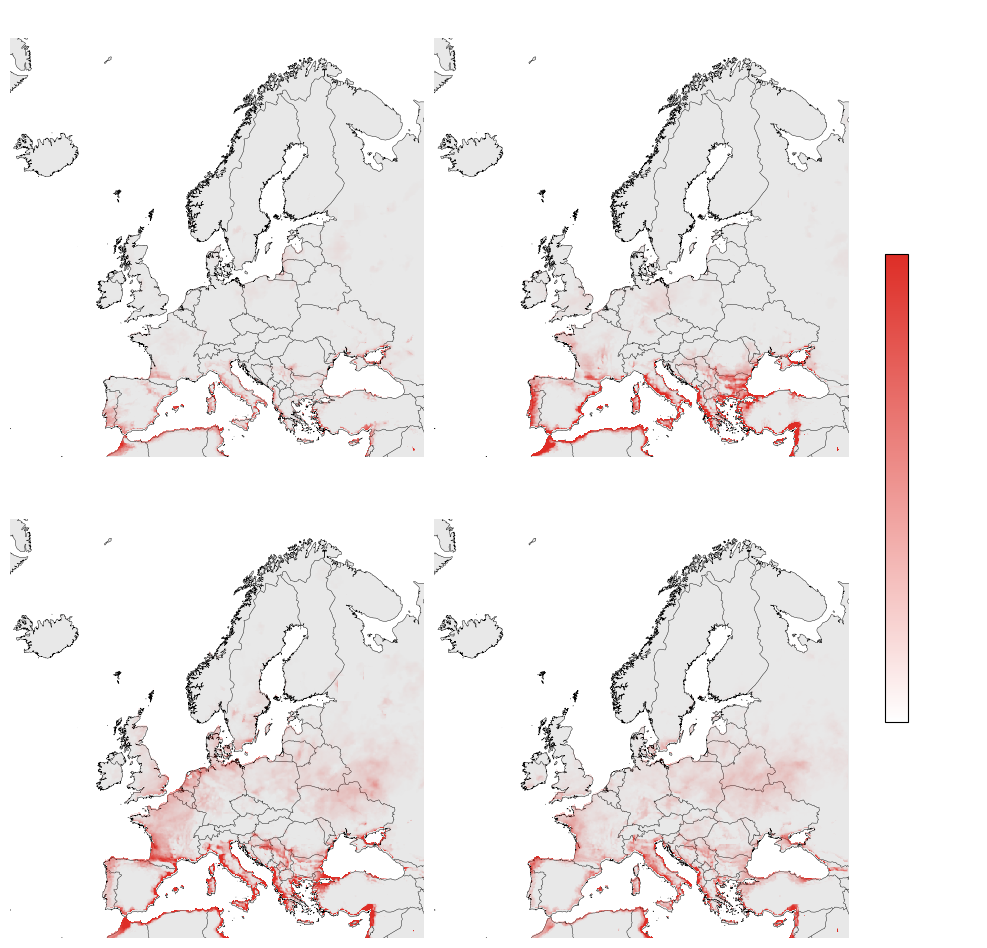

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import contextily as ctx
from pyproj import Transformer
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams.update({
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "font.weight": "bold",
    "font.size": 16        # 👈 set default font size here
})


# Monthly aggregation
ds_monthly = ds.resample(time='1ME').mean()

# Define selected months
selected_months_dt = pd.date_range('2020-06-30', '2020-09-30', freq='M')

# Create a transparent-to-red colormap
reds = cm.get_cmap("Reds")  # base reds colormap
colors = reds(np.linspace(0, 1, 256))
colors[:, -1] = np.linspace(0, 1, 256)  # set alpha from 0 (transparent) to 1 (opaque)
transparent_reds = mcolors.ListedColormap(colors)
def transparent_cmap(base_cmap="Reds", N=256):
    """
    Create a version of a colormap that goes from transparent to full color.
    
    Parameters
    ----------
    base_cmap : str or Colormap
        Any matplotlib colormap name (e.g. "viridis", "plasma", "coolwarm", "Blues")
    N : int
        Number of discrete color levels
    
    Returns
    -------
    ListedColormap
        Modified colormap with alpha going from 0 → 1
    """
    cmap = cm.get_cmap(base_cmap, N)  # get the base cmap
    colors = cmap(np.linspace(0, 1, N))  # RGBA values
    colors[:, -1] = np.linspace(0, 1, N)  # overwrite alpha from 0 to 1
    return mcolors.ListedColormap(colors)

def transparent_single_color(hex_color="#de2d26", N=256):
    """
    Make a colormap that goes from transparent to the given color.
    """
    rgb = mcolors.to_rgb(hex_color)        # take the chosen color
    colors = np.zeros((N, 4))              # RGBA array
    colors[:, :3] = rgb                    # keep same R,G,B
    colors[:, 3] = np.linspace(0, 1, N)    # alpha goes from 0 → 1
    return mcolors.ListedColormap(colors)

# Use your color
# Colormap
cmap = "Reds"
cmap = transparent_reds
cmap = transparent_cmap("crest")       # seaborn colormap (also works)
cmap = transparent_cmap("flare")        # standard matplotlib colormap
cmap = transparent_single_color("#de2d26")

# Shared color scale (99th percentile to avoid outliers)
vmin = 0
vmax = 100#
# selct as vmax the maximum value across all selected months
vmax = ds_monthly['WeeklyRates'].sel(time=selected_months_dt).max().item()
vmax = ds_monthly['WeeklyRates'].sel(time=selected_months_dt).quantile(0.99).item()
#vmax = 50
print("vmax:", vmax)

# ---- Build lon/lat EDGES (not centers) and project to Web Mercator ----
lons = ds['longitude'].values  # 1D
lats = ds['latitude'].values   # 1D

def to_edges(arr):
    mid = (arr[:-1] + arr[1:]) / 2.0
    first = arr[0] - (mid[0] - arr[0])
    last  = arr[-1] + (arr[-1] - mid[-1])
    return np.concatenate(([first], mid, [last]))

lon_e = to_edges(lons)
lat_e = to_edges(lats)

# 2D edges grid in geographic
lon_e2d, lat_e2d = np.meshgrid(lon_e, lat_e)

# project to EPSG:3857
to_merc = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
Xe_flat, Ye_flat = to_merc.transform(lon_e2d.ravel(), lat_e2d.ravel())
Xe = Xe_flat.reshape(lon_e2d.shape)
Ye = Ye_flat.reshape(lat_e2d.shape)

# global limits for all panels
xmin, xmax = float(np.nanmin(Xe)), float(np.nanmax(Xe))
ymin, ymax = float(np.nanmin(Ye)), float(np.nanmax(Ye))

# Create 2x2 grid
#fig, axs = plt.subplots(2, 2, figsize=(10, 10))
#axs = axs.flatten()
import cartopy.crs as ccrs

fig, axs = plt.subplots(2, 2, figsize=(10, 10),
                        subplot_kw={'projection': ccrs.Mercator()})
axs = axs.flatten()

# adjust space between subplots
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
# Adjust spacing (avoid negative hspace which can visually crop)
plt.subplots_adjust(hspace=.15, wspace=0.02)

# ---- Axis limits from projected grid (with small padding) ----
xmin, xmax = Xe.min(), Xe.max()
ymin, ymax = Ye.min(), Ye.max()

# add 2% padding
dx = (xmax - xmin) * 0.001
dy = (ymax - ymin) * 0.001

xmin, xmax = xmin - dx, xmax + dx
ymin, ymax = ymin - dy, ymax + dy


# Plot each selected month
for i, date in enumerate(selected_months_dt):
    ax = axs[i]

    monthly_data = ds_monthly['WeeklyRates'].sel(time=date).values  # 2D (ny, nx)

    # Underlay tiles first (low zorder) and DON'T reset extent
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    #ctx.add_basemap(ax, crs="EPSG:3857",
    #                source=ctx.providers.CartoDB.Positron,
    #                reset_extent=False,
    #                attribution=False,   # <- disable default bottom text
    #                alpha=0.3  # Make basemap semi-transparent
    #)

    # inside your loop, after setting extent:
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5, zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='none', alpha=0.0, zorder=0)  # fully transparent sea
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='black', zorder=1)
    ax.coastlines(resolution='10m', linewidth=0.3, color='black', zorder=1)


    # Plot raster on top using EDGES grid
    ax.pcolormesh(
        Xe, Ye, monthly_data,
        shading='auto',  # with edges, this won’t drop a row/col
        cmap=cmap, vmin=vmin, vmax=vmax,
        zorder=2,
        
    )
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(f"{date.strftime('%B')}")#, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect('equal')   # keep correct proportions between lon/lat

for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)

# Shared colorbar
norm = Normalize(vmin=vmin, vmax=vmax)
mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(
    mappable, ax=axs, orientation='vertical',
    fraction=0.026, pad=0.04, label='Eggs Weekly Rates'
)
ax.set_facecolor('none')   # transparent background
fig.patch.set_alpha(0)     # transparent figure background

# Make titles white and bold
for ax in axs:
    ax.title.set_color("white")
    ax.title.set_weight("bold")

# Make colorbar label white and bold
cbar.ax.yaxis.label.set_color("white")
cbar.ax.yaxis.label.set_weight("bold")

# Make colorbar tick labels white and bold
for t in cbar.ax.get_yticklabels():
    t.set_color("white")
    t.set_weight("bold")


#fig.suptitle('Mosquito Weekly Rates', fontsize=14, y=0.95)
plt.savefig("./weekly_rates_map_poster.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()


# RUN THE FOLLOWING CODE TO PRODUCE THE RESULTS DATA FOR THE MAP: predictions_2020_weekly_rates.nc


In [ ]:
from AIedes.data_loader.counter_normalization_stats import normalize_dataframe, create_flagged_weekly_rates

def process_climate_data_for_date(ds, selected_date, delta_days=89):    
    """
    Processes climate data for a specific date, creating a DataFrame for model input.

    Args:
        ds (xr.Dataset): The input climate dataset.
        selected_date (np.datetime64): The selected date.

    Returns:
        pd.DataFrame: A DataFrame containing the processed climate variables.
        xr.Dataset: The windowed dataset.
        xr.DataArray: The total precipitation data array from the window.
    """
    window_start = selected_date - np.timedelta64(delta_days, "D")
    window_end = selected_date

    ds_window = ds.sel(time=slice(window_start, window_end))

    # Extract variables
    tp = ds_window["total_precipitation_sum"]
    temp = ds_window["2m_temperature_mean"]
    dew = ds_window["2m_dewpoint_temperature_mean"]

    # Stack lat/lon
    tp_stack = tp.stack(grid=("latitude", "longitude"))
    temp_stack = temp.stack(grid=("latitude", "longitude"))
    dew_stack = dew.stack(grid=("latitude", "longitude"))

    # Select WeeklyRates from 7 and 14 days before the selected_date
    prev_wr = ds["WeeklyRates"].sel(time=selected_date - np.timedelta64(7, "D"))
    prev2_wr = ds["WeeklyRates"].sel(time=selected_date - np.timedelta64(14, "D"))

    # Stack the single-day data
    prev_wr_stack = prev_wr.stack(grid=("latitude", "longitude"))
    prev2_wr_stack = prev2_wr.stack(grid=("latitude", "longitude"))

    # Create a mask for grid points that have any NaN values in temp, tp, or dew over the time window
    nan_mask_temp = temp_stack.isnull().any(dim="time")
    nan_mask_tp = tp_stack.isnull().any(dim="time")
    nan_mask_dew = dew_stack.isnull().any(dim="time")
    nan_mask = nan_mask_temp | nan_mask_tp | nan_mask_dew

    # Get the grid coordinates that are not NaN
    valid_grid_points = temp_stack.grid[~nan_mask]

    # Filter all stacked data using the valid grid points
    tp_stack = tp_stack.sel(grid=valid_grid_points)
    temp_stack = temp_stack.sel(grid=valid_grid_points)
    dew_stack = dew_stack.sel(grid=valid_grid_points)
    prev_wr_stack = prev_wr_stack.sel(grid=valid_grid_points)
    prev2_wr_stack = prev2_wr_stack.sel(grid=valid_grid_points)


    # Build DataFrame efficiently
    df_processed = pd.DataFrame({
        "latitude": temp_stack.coords['latitude'].values,
        "longitude": temp_stack.coords['longitude'].values,
        "date": selected_date,
        "tp_sum": list(tp_stack.values.T),
        "t2m_mean": list(temp_stack.values.T),
        "d2m_mean": list(dew_stack.values.T),
        "prev1_rates": prev_wr_stack.values,
        "prev2_rates": prev2_wr_stack.values
    })
    

    # Normalize the DataFrame
    df_processed = normalize_dataframe(df_processed)
    # Create flagged weekly rates
    df_processed = create_flagged_weekly_rates(df_processed)
    
    return df_processed

def create_climate_tensor(df, input_variables):
    """
    Creates a tensor from the DataFrame for model input.

    Args:
        df (pd.DataFrame): The processed DataFrame.
        input_variables (str): The string of input variable names.

    Returns:
        torch.Tensor: A tensor containing the input variables.
    """
    climate = []
    input_vars = input_variables.split("+")
    data_egg = df
    for var in input_vars:
        print(var)
        if var not in data_egg:
            print(f"Warning: Variable {var} not found. Skipping.")
            continue

        # stack into shape (n_samples, n_days)
        var_data = np.vstack(data_egg[var])
        # check Nan
        if np.isnan(var_data).any():
            print(f"Warning: NaN detected in variable {var}.")
            # Optionally, you can handle NaNs here, e.g., fill with zeros or drop rows
            var_data = np.nan_to_num(var_data)  # Replace NaNs with 0
        # 1) truncate to last cfg['days'] if requested
        climate.append(var_data)

    climate_tensor = np.concatenate(
        [v.reshape(v.shape[0], -1) for v in climate],
        axis=-1
    )
    
    return climate_tensor

def run_model(model, climate_tensor):
    """
    Runs the model on the input tensor and returns the predictions.

    Args:
        model (torch.nn.Module): The trained model.
        climate_tensor (torch.Tensor): The input tensor.

    Returns:
        torch.Tensor: The model predictions.
    """
    # Convert to torch tensor
    climate_tensor = torch.tensor(climate_tensor, dtype=torch.float32)
    
    # Ensure the model is in evaluation mode
    model.eval()
    
    with torch.no_grad():
        predictions = model(climate_tensor)
    predictions_df = pd.DataFrame(predictions.numpy(), columns=["Predicted_WeeklyRates"])
    # Combine predictions with the original DataFrame

    return predictions_df



# Select the date
# loop on the dates in the dataset from the march 5 to the end of the year
for date in ds.time.values:
    if date >= np.datetime64("2020-04-01") and date <= np.datetime64("2020-12-31"):
        print(f"processing date: {date}")  
        selected_date = date

        # Process the data for the selected date
        df = process_climate_data_for_date(ds, selected_date)
        climate_tensor = create_climate_tensor(df, input_variables)
        predictions_df = run_model(model, climate_tensor)
        # Combine predictions with the original DataFrame
        df['Predicted_WeeklyRates'] = predictions_df['Predicted_WeeklyRates']
        # Create a MultiIndex from the original coordinates
        original_coords = pd.MultiIndex.from_arrays([
            ds.latitude.values.repeat(len(ds.longitude)), 
            np.tile(ds.longitude.values, len(ds.latitude))
        ], names=['latitude', 'longitude'])

        # Create a Series with NaN values
        result_series = pd.Series(np.nan, index=original_coords)

        # Set the predictions using DataFrame index
        df_indexed = df.set_index(['latitude', 'longitude'])
        result_series.loc[df_indexed.index] = df_indexed['Predicted_WeeklyRates']

        # Reshape back to 2D and assign
        predictions_2d = result_series.values.reshape(len(ds.latitude), len(ds.longitude))
        ds['WeeklyRates'].loc[dict(time=selected_date)] = predictions_2d

# save ds
output_file = f"../../data/predictions_{yr}_weekly_rates.nc"
ds.to_netcdf(output_file, mode='w', format='NETCDF4')
print(f"Predictions saved to {output_file}")

processing date: 2020-04-01T00:00:00.000000000
Normalized 5 fields: ['tp_sum', 'd2m_mean', 't2m_mean', 'prev1_rates', 'prev2_rates']
Skipped 29 fields: ['u10_min (missing)', 'u10_max (missing)', 'u10_mean (missing)', 'v10_min (missing)', 'v10_max (missing)', 'v10_mean (missing)', 'd2m_min (missing)', 'd2m_max (missing)', 't2m_min (missing)', 't2m_max (missing)', 'swvl1_min (missing)', 'swvl1_max (missing)', 'swvl1_mean (missing)', 'tp_sum_monthly (missing)', 'u10_min_monthly (missing)', 'u10_max_monthly (missing)', 'u10_mean_monthly (missing)', 'v10_min_monthly (missing)', 'v10_max_monthly (missing)', 'v10_mean_monthly (missing)', 'd2m_min_monthly (missing)', 'd2m_max_monthly (missing)', 'd2m_mean_monthly (missing)', 't2m_min_monthly (missing)', 't2m_max_monthly (missing)', 't2m_mean_monthly (missing)', 'swvl1_min_monthly (missing)', 'swvl1_max_monthly (missing)', 'swvl1_mean_monthly (missing)']
t2m_mean_znorm
d2m_mean_znorm
tp_sum_znorm
p1zn
p2zn
processing date: 2020-04-02T00:00:00.0